# Verify Quantization Claims (PTQ/QAT)

This notebook verifies and completes the following claims using stored experiment results:

1. INT8 Static PTQ: average accuracy drop around -0.01% across 16 models.
2. INT4 PTQ: significant degradation (up to ~20%), especially at high structured pruning rates.
3. INT4 QAT: complete the missing claim from measured data.

In [18]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
QUANT_DIR = ROOT / "quantization"

PTQ8_PATH = QUANT_DIR / "unstructured_pruning_ptq_results.json"
PTQ4_PATH = QUANT_DIR / "unstructured_pruning_ptq_4bit_results.json"
QAT4_PATH = QUANT_DIR / "unstructured_pruning_qat_4bit_results.json"

for p in [PTQ8_PATH, PTQ4_PATH, QAT4_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using files:")
print(f"- {PTQ8_PATH}")
print(f"- {PTQ4_PATH}")
print(f"- {QAT4_PATH}")

Using files:
- /homes/m24janat/efficient-deep-learning/pytorch-cifar/quantization/unstructured_pruning_ptq_results.json
- /homes/m24janat/efficient-deep-learning/pytorch-cifar/quantization/unstructured_pruning_ptq_4bit_results.json
- /homes/m24janat/efficient-deep-learning/pytorch-cifar/quantization/unstructured_pruning_qat_4bit_results.json


In [19]:
def parse_checkpoint_meta(checkpoint_name: str):
    # Example: Resnet18_unstructured_pruned_70_basemodel_0.7structured_augmix_30ep.pth
    m_u = re.search(r"unstructured_pruned_(\d+)", checkpoint_name)
    m_s = re.search(r"basemodel_(\d*\.?\d+)structured", checkpoint_name)
    u = float(m_u.group(1)) / 100.0 if m_u else None
    s = float(m_s.group(1)) if m_s else None
    return u, s

ptq8_raw = json.loads(PTQ8_PATH.read_text(encoding="utf-8"))
ptq4_raw = json.loads(PTQ4_PATH.read_text(encoding="utf-8"))
qat4_raw = json.loads(QAT4_PATH.read_text(encoding="utf-8"))

ptq8_df = pd.DataFrame(ptq8_raw["results"]).copy()
ptq8_df["method"] = "PTQ_INT8"

ptq4_df = pd.DataFrame(ptq4_raw["results"]).copy()
ptq4_df["method"] = "PTQ_INT4"

qat4_df = pd.DataFrame(qat4_raw).copy()
qat4_df["method"] = "QAT_INT4"

for df in [ptq8_df, ptq4_df, qat4_df]:
    df[["unstructured_rate", "structured_rate"]] = df["checkpoint"].apply(
        lambda x: pd.Series(parse_checkpoint_meta(x))
    )

display(ptq8_df.head(3))
display(ptq4_df.head(3))
display(qat4_df.head(3))

,checkpoint,int8_checkpoint,fp32_test_loss,fp32_test_acc,int8_test_loss,int8_test_acc,acc_drop,method,unstructured_rate,structured_rate
0,Resnet18_unstructured_pruned_10_basemodel_0.1s...,Resnet18_unstructured_pruned_10_basemodel_0.1s...,0.251583,95.45,0.251975,95.40,0.05,PTQ_INT8,0.1,0.1
1,Resnet18_unstructured_pruned_10_basemodel_0.3s...,Resnet18_unstructured_pruned_10_basemodel_0.3s...,0.338792,93.47,0.339134,93.64,-0.17,PTQ_INT8,0.1,0.3
2,Resnet18_unstructured_pruned_10_basemodel_0.5s...,Resnet18_unstructured_pruned_10_basemodel_0.5s...,0.376501,93.25,0.374615,93.22,0.03,PTQ_INT8,0.1,0.5


,checkpoint,int4_checkpoint,fp32_test_loss,fp32_test_acc,int4_test_loss,int4_test_acc,acc_drop,method,unstructured_rate,structured_rate
0,Resnet18_unstructured_pruned_10_basemodel_0.1s...,Resnet18_unstructured_pruned_10_basemodel_0.1s...,0.251583,95.45,0.456547,87.62,7.83,PTQ_INT4,0.1,0.1
1,Resnet18_unstructured_pruned_10_basemodel_0.3s...,Resnet18_unstructured_pruned_10_basemodel_0.3s...,0.338792,93.47,0.572267,83.35,10.12,PTQ_INT4,0.1,0.3
2,Resnet18_unstructured_pruned_10_basemodel_0.5s...,Resnet18_unstructured_pruned_10_basemodel_0.5s...,0.376501,93.25,0.618857,82.20,11.05,PTQ_INT4,0.1,0.5


,checkpoint,fp32_test_acc,int4_test_acc,acc_drop,method,unstructured_rate,structured_rate
0,Resnet18_unstructured_pruned_10_basemodel_0.1s...,95.45,94.49,0.96,QAT_INT4,0.1,0.1
1,Resnet18_unstructured_pruned_10_basemodel_0.3s...,93.47,92.78,0.69,QAT_INT4,0.1,0.3
2,Resnet18_unstructured_pruned_10_basemodel_0.5s...,93.25,92.55,0.70,QAT_INT4,0.1,0.5


In [20]:
# Basic integrity checks
assert len(ptq8_df) == 16, f"Expected 16 INT8 PTQ models, got {len(ptq8_df)}"
assert len(ptq4_df) == 16, f"Expected 16 INT4 PTQ models, got {len(ptq4_df)}"
assert len(qat4_df) == 16, f"Expected 16 INT4 QAT models, got {len(qat4_df)}"

def summarize(df, name):
    mean_drop = df["acc_drop"].mean()
    median_drop = df["acc_drop"].median()
    min_drop = df["acc_drop"].min()
    max_drop = df["acc_drop"].max()
    std_drop = df["acc_drop"].std()
    print(f"{name}:")
    print(f"  count       = {len(df)}")
    print(f"  mean drop   = {mean_drop:.4f}%")
    print(f"  median drop = {median_drop:.4f}%")
    print(f"  min drop    = {min_drop:.4f}%")
    print(f"  max drop    = {max_drop:.4f}%")
    print(f"  std         = {std_drop:.4f}%")
    print()

summarize(ptq8_df, "INT8 Static PTQ")
summarize(ptq4_df, "INT4 PTQ")
summarize(qat4_df, "INT4 QAT")

print("INT4 PTQ mean drop by structured pruning rate:")
display(ptq4_df.groupby("structured_rate")["acc_drop"].agg(["mean", "min", "max"]).round(4))

print("INT4 QAT mean drop by structured pruning rate:")
display(qat4_df.groupby("structured_rate")["acc_drop"].agg(["mean", "min", "max"]).round(4))

INT8 Static PTQ:
  count       = 16
  mean drop   = -0.0144%
  median drop = 0.0000%
  min drop    = -0.1700%
  max drop    = 0.1100%
  std         = 0.0761%

INT4 PTQ:
  count       = 16
  mean drop   = 11.4000%
  median drop = 10.1300%
  min drop    = 7.8300%
  max drop    = 20.1700%
  std         = 3.3856%

INT4 QAT:
  count       = 16
  mean drop   = 1.0375%
  median drop = 0.9500%
  min drop    = 0.6900%
  max drop    = 1.5100%
  std         = 0.2905%

INT4 PTQ mean drop by structured pruning rate:


,mean,min,max
structured_rate,,,
0.1,8.7300,7.83,9.27
0.3,10.9875,8.85,14.84
0.5,10.1550,7.93,12.62
0.7,15.7275,14.12,20.17


INT4 QAT mean drop by structured pruning rate:


,mean,min,max
structured_rate,,,
0.1,0.8825,0.74,0.96
0.3,0.8450,0.69,0.98
0.5,0.9400,0.70,1.14
0.7,1.4825,1.45,1.51


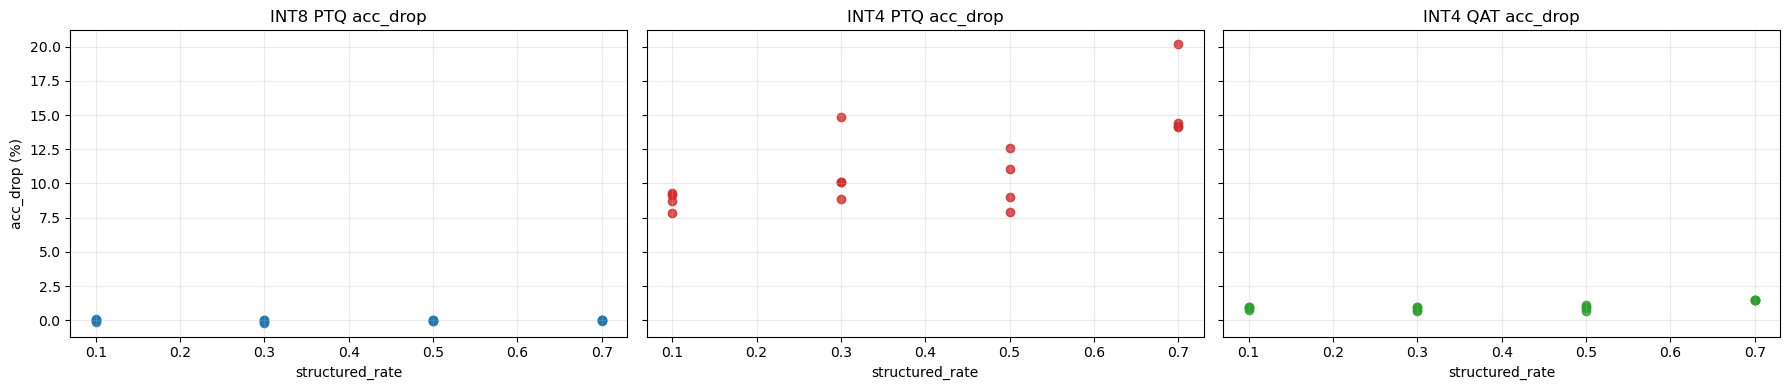

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

axes[0].scatter(ptq8_df["structured_rate"], ptq8_df["acc_drop"], alpha=0.8)
axes[0].set_title("INT8 PTQ acc_drop")
axes[0].set_xlabel("structured_rate")
axes[0].set_ylabel("acc_drop (%)")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(ptq4_df["structured_rate"], ptq4_df["acc_drop"], alpha=0.8, color="tab:red")
axes[1].set_title("INT4 PTQ acc_drop")
axes[1].set_xlabel("structured_rate")
axes[1].grid(True, alpha=0.25)

axes[2].scatter(qat4_df["structured_rate"], qat4_df["acc_drop"], alpha=0.8, color="tab:green")
axes[2].set_title("INT4 QAT acc_drop")
axes[2].set_xlabel("structured_rate")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

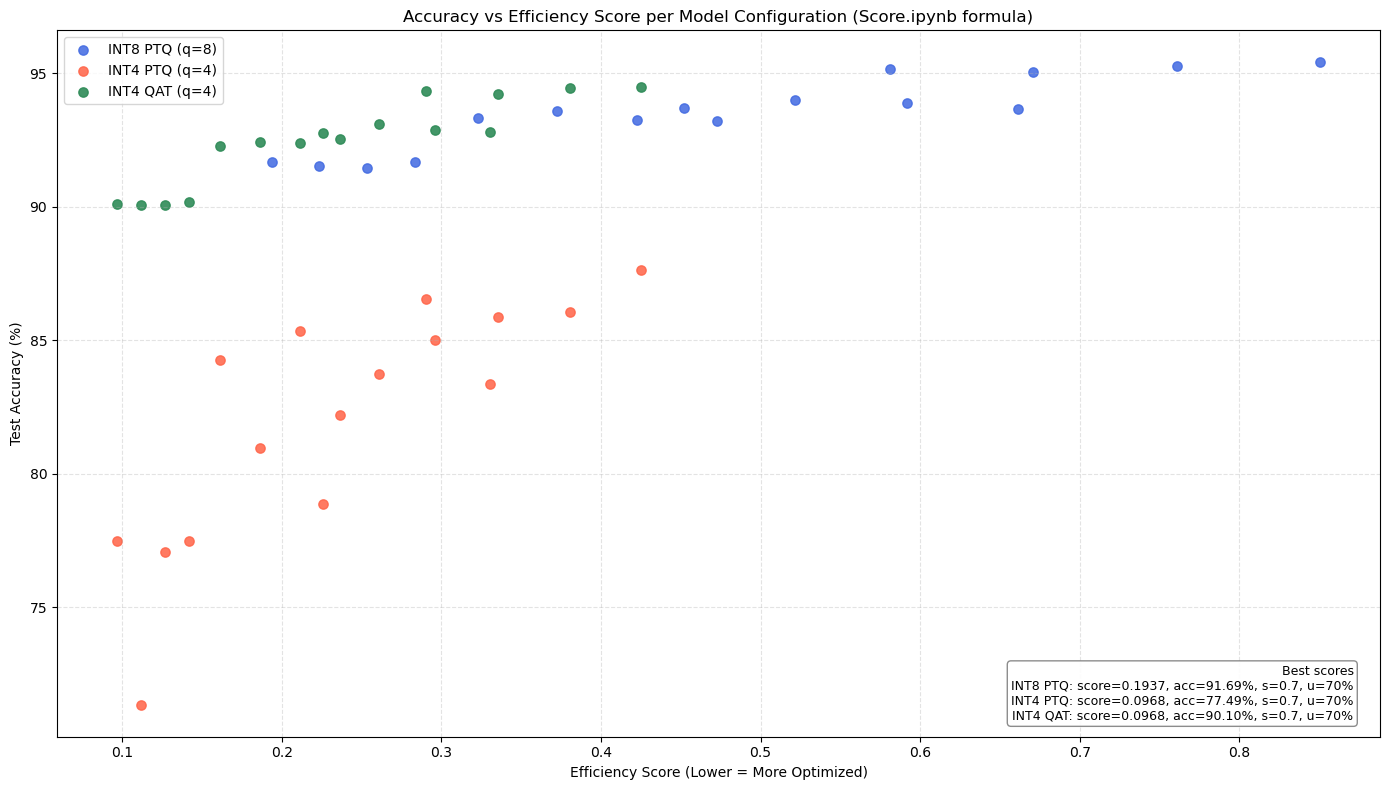

In [22]:
# Combined plot with EXACT Score.ipynb scoring setup
import torch
import torch.nn as nn
from models import ResNet18

REF_PARAMS = 5.6e6
REF_OPS = 2.8e8

def compute_pruning_ratios_from_amounts(amount_s, amount_u):
    if not (0.0 <= amount_s <= 1.0 and 0.0 <= amount_u <= 1.0):
        raise ValueError("amount_s and amount_u must be in [0, 1].")
    p_s = float(amount_s)
    p_u = (1.0 - p_s) * float(amount_u)
    return p_s, p_u

def compute_effdl_score(amount_s, amount_u, q_w, q_a, w, f, ref_params=REF_PARAMS, ref_ops=REF_OPS):
    p_s, p_u = compute_pruning_ratios_from_amounts(amount_s, amount_u)
    if min(q_w, q_a, w, f) < 0:
        raise ValueError("q_w, q_a, w and f must be non-negative.")

    params_term = (1.0 - (p_s + p_u)) * ((q_w / 32.0) * w) / ref_params
    ops_term = (1.0 - p_s) * (max(q_w, q_a) / 32.0) * f / ref_ops
    return params_term + ops_term

def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters())

def count_ops_single_forward(model: nn.Module, input_shape=(1, 3, 32, 32)):
    model.eval()
    total_ops = 0
    hooks = []

    def conv_hook(module, inp, out):
        nonlocal total_ops
        out_tensor = out if isinstance(out, torch.Tensor) else out[0]
        n, cout, hout, wout = out_tensor.shape
        cin = module.in_channels
        kh, kw = module.kernel_size
        groups = module.groups
        ops_per_out = (cin // groups) * kh * kw
        total_ops += n * cout * hout * wout * ops_per_out

    def linear_hook(module, inp, out):
        nonlocal total_ops
        out_tensor = out if isinstance(out, torch.Tensor) else out[0]
        n = out_tensor.shape[0]
        total_ops += n * module.in_features * module.out_features

    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))

    with torch.no_grad():
        x = torch.randn(*input_shape)
        model(x)

    for h in hooks:
        h.remove()

    return int(total_ops)

# Same architecture assumption as these quantization sweeps: ResNet18
resnet18 = ResNet18()
w_resnet18 = float(count_params(resnet18))
f_resnet18 = float(count_ops_single_forward(resnet18))

plot_int8 = ptq8_df.copy()
plot_int4_ptq = ptq4_df.copy()
plot_int4_qat = qat4_df.copy()

plot_int8["score"] = plot_int8.apply(
    lambda r: compute_effdl_score(
        amount_s=r["structured_rate"],
        amount_u=r["unstructured_rate"],
        q_w=8.0,
        q_a=8.0,
        w=w_resnet18,
        f=f_resnet18,
    ),
    axis=1,
 )
plot_int4_ptq["score"] = plot_int4_ptq.apply(
    lambda r: compute_effdl_score(
        amount_s=r["structured_rate"],
        amount_u=r["unstructured_rate"],
        q_w=4.0,
        q_a=4.0,
        w=w_resnet18,
        f=f_resnet18,
    ),
    axis=1,
 )
plot_int4_qat["score"] = plot_int4_qat.apply(
    lambda r: compute_effdl_score(
        amount_s=r["structured_rate"],
        amount_u=r["unstructured_rate"],
        q_w=4.0,
        q_a=4.0,
        w=w_resnet18,
        f=f_resnet18,
    ),
    axis=1,
 )

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(plot_int8["score"], plot_int8["int8_test_acc"], c="royalblue", s=45, alpha=0.85, label="INT8 PTQ (q=8)")
ax.scatter(plot_int4_ptq["score"], plot_int4_ptq["int4_test_acc"], c="tomato", s=45, alpha=0.85, label="INT4 PTQ (q=4)")
ax.scatter(plot_int4_qat["score"], plot_int4_qat["int4_test_acc"], c="seagreen", s=45, alpha=0.9, label="INT4 QAT (q=4)")

# Best (lowest-score) configuration per method
best_int8 = plot_int8.loc[plot_int8["score"].idxmin()]
best_int4_ptq = plot_int4_ptq.loc[plot_int4_ptq["score"].idxmin()]
best_int4_qat = plot_int4_qat.loc[plot_int4_qat["score"].idxmin()]

best_text = (
    "Best scores\n"
    f"INT8 PTQ: score={best_int8['score']:.4f}, "
    f"acc={best_int8['int8_test_acc']:.2f}%, "
    f"s={best_int8['structured_rate']:.1f}, u={int(round(best_int8['unstructured_rate'] * 100))}%\n"
    f"INT4 PTQ: score={best_int4_ptq['score']:.4f}, "
    f"acc={best_int4_ptq['int4_test_acc']:.2f}%, "
    f"s={best_int4_ptq['structured_rate']:.1f}, u={int(round(best_int4_ptq['unstructured_rate'] * 100))}%\n"
    f"INT4 QAT: score={best_int4_qat['score']:.4f}, "
    f"acc={best_int4_qat['int4_test_acc']:.2f}%, "
    f"s={best_int4_qat['structured_rate']:.1f}, u={int(round(best_int4_qat['unstructured_rate'] * 100))}%"
 )

ax.text(
    0.98,
    0.02,
    best_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.set_title("Accuracy vs Efficiency Score per Model Configuration (Score.ipynb formula)")
ax.set_xlabel("Efficiency Score (Lower = More Optimized)")
ax.set_ylabel("Test Accuracy (%)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [23]:
int8_mean = ptq8_df["acc_drop"].mean()
int8_max_abs = ptq8_df["acc_drop"].abs().max()

int4_ptq_mean = ptq4_df["acc_drop"].mean()
int4_ptq_max = ptq4_df["acc_drop"].max()

int4_qat_mean = qat4_df["acc_drop"].mean()
int4_qat_max = qat4_df["acc_drop"].max()

s07_ptq_mean = ptq4_df.loc[ptq4_df["structured_rate"] == 0.7, "acc_drop"].mean()
s07_qat_mean = qat4_df.loc[qat4_df["structured_rate"] == 0.7, "acc_drop"].mean()

print("Slide-ready validated claims:")
print()
print(
    f"INT8 Static PTQ: Applied post-pruning via PyTorch FX Graph Mode. "
    f"Across 16 models, average accuracy drop is {int8_mean:+.2f}% "
    f"(max absolute change {int8_max_abs:.2f}%)."
)

print(
    f"INT4 PTQ Quantization: Significant accuracy degradation observed, "
    f"with average drop {int4_ptq_mean:.2f}% and worst-case drop {int4_ptq_max:.2f}%. "
    f"At structured pruning rate 0.7, mean drop is {s07_ptq_mean:.2f}%."
)

print(
    f"INT4 QAT Quantization: Fine-tuning after quantization recovers most of the PTQ loss; "
    f"across 16 models, average drop is only {int4_qat_mean:.2f}% and worst-case drop is {int4_qat_max:.2f}%. "
    f"At structured pruning rate 0.7, mean drop is {s07_qat_mean:.2f}%."
)

Slide-ready validated claims:

INT8 Static PTQ: Applied post-pruning via PyTorch FX Graph Mode. Across 16 models, average accuracy drop is -0.01% (max absolute change 0.17%).
INT4 PTQ Quantization: Significant accuracy degradation observed, with average drop 11.40% and worst-case drop 20.17%. At structured pruning rate 0.7, mean drop is 15.73%.
INT4 QAT Quantization: Fine-tuning after quantization recovers most of the PTQ loss; across 16 models, average drop is only 1.04% and worst-case drop is 1.51%. At structured pruning rate 0.7, mean drop is 1.48%.


## Notes
- `acc_drop` is interpreted as `fp32_test_acc - quantized_test_acc` (percentage points).
- Positive values mean quantization reduced accuracy; negative values mean a slight gain.
- Claims are data-backed by the three JSON result files in `pytorch-cifar/quantization`.